In [40]:
import pandas as pd

df = pd.read_json("output_dataset.json")

df.head(5)

print(len(df))

111


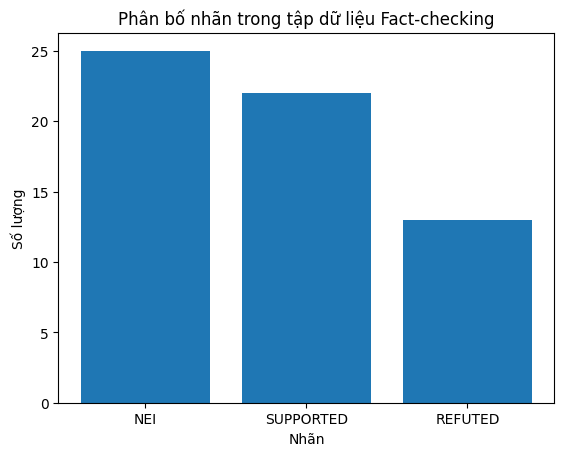

In [41]:
import matplotlib.pyplot as plt

plt.bar(counts.index,counts.values)
plt.xlabel("Nhãn")
plt.ylabel("Số lượng")
plt.title("Phân bố nhãn trong tập dữ liệu Fact-checking")
plt.xticks(rotation=0)
plt.show()

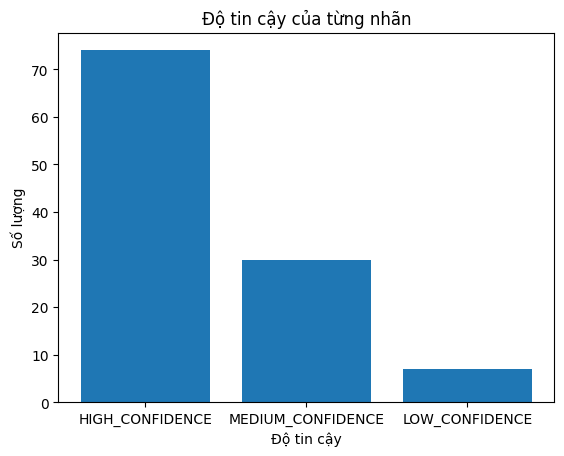

In [42]:
status_cnt = df['status'].value_counts()

plt.bar(status_cnt.index, status_cnt.values)    
plt.xlabel("Độ tin cậy")
plt.ylabel("Số lượng")
plt.title("Độ tin cậy của từng nhãn")
plt.show()

In [43]:
import pandas as pd
import numpy as np
from sklearn.metrics import cohen_kappa_score

# Bước 1: Trích xuất vote của từng model thành các cột riêng biệt
def extract_model_votes(voter_details, model_name):
    for vote_info in voter_details:
        if vote_info['model'] == model_name:
            return vote_info['vote']
    return None

df['gpt_vote'] = df['voter_details'].apply(lambda x: extract_model_votes(x, 'openai/gpt-4o-mini'))
df['qwen_vote'] = df['voter_details'].apply(lambda x: extract_model_votes(x, 'qwen/qwen-2.5-72b-instruct'))
df['mistral_vote'] = df['voter_details'].apply(lambda x: extract_model_votes(x, 'mistralai/mistral-small-24b-instruct-2501'))

# Loại bỏ các dòng có giá trị None (nếu có model nào chưa vote dòng đó)
df_clean = df.dropna(subset=['gpt_vote', 'qwen_vote', 'mistral_vote'])

# Tính Kappa giữa từng cặp
kappa_gpt_qwen = cohen_kappa_score(df_clean['gpt_vote'], df_clean['qwen_vote'])
kappa_gpt_mistral = cohen_kappa_score(df_clean['gpt_vote'], df_clean['mistral_vote'])
kappa_qwen_mistral = cohen_kappa_score(df_clean['qwen_vote'], df_clean['mistral_vote'])

print(f"Kappa GPT vs Qwen: {kappa_gpt_qwen:.3f}")
print(f"Kappa GPT vs Mistral: {kappa_gpt_mistral:.3f}")
print(f"Kappa Qwen vs Mistral: {kappa_qwen_mistral:.3f}")

Kappa GPT vs Qwen: 0.612
Kappa GPT vs Mistral: 0.631
Kappa Qwen vs Mistral: 0.757


In [44]:
from statsmodels.stats.inter_rater import fleiss_kappa, aggregate_raters

# Chuyển đổi dữ liệu sang dạng ma trận đếm nhãn cho mỗi dòng
# Ví dụ: Dòng 1 có [SUPPORTED, SUPPORTED, REFUTED] -> thành [2, 1, 0] (tương ứng các nhãn)
voter_matrix = df_clean[['gpt_vote', 'qwen_vote', 'mistral_vote']].values
agg_data, categories = aggregate_raters(voter_matrix)

overall_kappa = fleiss_kappa(agg_data)
print(f"Fleiss' Kappa (Tổng thể 3 model): {overall_kappa:.3f}")

Fleiss' Kappa (Tổng thể 3 model): 0.665


In [47]:
df['claim'].to_csv("claim.csv")

In [48]:
df_claim = pd.read_json("../claim/claims_output.json")

df_claim.head(5)

,claim_id,claim,label,seed_context_id,seed_context
0,ctx1_claim1,Ông Sơn cho biết việc nâng cấp đường Nguyễn Tấ...,SUPPORTED,vne_432_chunk_3,"Theo ông Sơn, dù đây là thời điểm thích hợp ch..."
1,ctx1_claim2,"Theo ông Sơn, đường Nguyễn Tất Thành nên được ...",REFUTED,vne_432_chunk_3,"Theo ông Sơn, dù đây là thời điểm thích hợp ch..."
2,ctx1_claim3,Ông Sơn khẳng định việc chỉnh trang đường Nguy...,NEI,vne_432_chunk_3,"Theo ông Sơn, dù đây là thời điểm thích hợp ch..."
3,ctx2_claim4,"Vào ngày 8 tháng 3 năm 2014, chuyến bay MH370 ...",SUPPORTED,vne_652_chunk_0,Tàu hậu cần viễn dương Armada 7806 mang theo đ...
4,ctx2_claim5,"Tàu hậu cần viễn dương Armada 7806, được đóng ...",REFUTED,vne_652_chunk_0,Tàu hậu cần viễn dương Armada 7806 mang theo đ...


In [ ]:
df_claim = df_claim[['claim', 'label']]

df_claim.to_csv("claim_1.csv")